In [ ]:
#%pip install pathlib collections-extended pillow matplotlib pandas ipython

   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------------------------- -------------- 4.5/7.1 MB 26.8 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 30.9 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.2 MB 123.0 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.2 MB 123.0 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.2 MB 6.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.2 MB 5.6 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 6.8 MB/s  0:00:01
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------------------- ------------------- 5.0/9.8 MB 121.0 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.8 MB 20.2 MB/s eta 0:00:01
   ----------------------- ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
from collections import defaultdict, Counter
import csv
import random
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


In [4]:
# ==========================
# НАСТРОЙКИ
# ==========================

ROOT = Path(r"F:\kurs_work\AOD 4\AOD 4")

IMAGES_ROOT = ROOT / "Images"
LABELS_ROOT = ROOT / "Annotations" / "YOLOv8 format"

OUTPUT_ROOT = ROOT / "analysis"
OUTPUT_ROOT.mkdir(exist_ok=True)

SPLITS = ["train", "valid", "test"]

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

CLASS_NAMES = {
    0: "airplane",
    1: "bird",
    2: "drone",
    3: "helicopter",
}


In [5]:
# ==========================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ==========================

def find_image_by_stem(folder: Path, stem: str):
    """
    Ищет изображение по имени без расширения.
    Например, для label-файла img_001.txt ищет img_001.jpg / img_001.jpeg / img_001.png.
    """
    for ext in IMAGE_EXTENSIONS:
        candidate = folder / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
def get_all_images(folder: Path):
    """
    Возвращает изображения без дублей.
    Сравниваем расширение через suffix.lower(), чтобы .jpg, .JPG, .PNG считались нормально.
    """
    return sorted(
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def parse_yolo_label(label_path: Path):
    """
    Читает YOLO-разметку.

    Поддерживает два варианта:
    1) detection bbox:
       class_id x_center y_center width height

    2) polygon / segmentation:
       class_id x1 y1 x2 y2 x3 y3 ...

    Во втором случае полигон автоматически переводится в обычный bbox.
    """
    objects = []
    errors = []

    if not label_path.exists():
        return objects, [f"Файл разметки не найден: {label_path}"]

    with open(label_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line_number, line in enumerate(lines, start=1):
        line = line.strip()

        if not line:
            continue

        parts = line.split()

        try:
            class_id = int(float(parts[0]))
        except ValueError:
            errors.append(f"{label_path}, строка {line_number}: class_id не является числом")
            continue

        if len(parts) == 5:
            try:
                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])
            except ValueError:
                errors.append(f"{label_path}, строка {line_number}: не удалось преобразовать bbox в числа")
                continue

            source_format = "bbox"

        elif len(parts) > 5 and (len(parts) - 1) % 2 == 0:
            try:
                coords = [float(value) for value in parts[1:]]
            except ValueError:
                errors.append(f"{label_path}, строка {line_number}: не удалось преобразовать polygon в числа")
                continue

            xs = coords[0::2]
            ys = coords[1::2]

            if len(xs) < 2 or len(ys) < 2:
                errors.append(f"{label_path}, строка {line_number}: слишком мало точек polygon")
                continue

            x_min = min(xs)
            x_max = max(xs)
            y_min = min(ys)
            y_max = max(ys)

            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2
            box_width = x_max - x_min
            box_height = y_max - y_min

            source_format = "polygon_converted_to_bbox"

        else:
            errors.append(
                f"{label_path}, строка {line_number}: неизвестный формат, получено {len(parts)} значений"
            )
            continue

        values = [x_center, y_center, box_width, box_height]

        if not all(0 <= value <= 1 for value in values):
            errors.append(f"{label_path}, строка {line_number}: координаты вне диапазона [0; 1]")

        if box_width <= 0 or box_height <= 0:
            errors.append(f"{label_path}, строка {line_number}: ширина или высота bbox <= 0")

        x_min = x_center - box_width / 2
        y_min = y_center - box_height / 2
        x_max = x_center + box_width / 2
        y_max = y_center + box_height / 2

        if x_min < 0 or y_min < 0 or x_max > 1 or y_max > 1:
            errors.append(f"{label_path}, строка {line_number}: рамка выходит за границы изображения")

        objects.append({
            "class_id": class_id,
            "x_center": x_center,
            "y_center": y_center,
            "box_width_norm": box_width,
            "box_height_norm": box_height,
            "x_min_norm": x_min,
            "y_min_norm": y_min,
            "x_max_norm": x_max,
            "y_max_norm": y_max,
            "source_format": source_format,
        })

    return objects, errors


def size_category(relative_area):
    """
    Делит объекты на группы по относительной площади bbox.
    Это не строгий стандарт COCO, а удобная шкала именно для воздушных объектов.
    """
    if relative_area < 0.01:
        return "tiny"
    if relative_area < 0.05:
        return "small"
    if relative_area < 0.20:
        return "medium"
    return "large"


# ==========================
# СОХРАНЕНИЕ CSV
# ==========================

def write_csv(path: Path, rows):
    if not rows:
        return

    with open(path, "w", newline="", encoding="utf-8-sig") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()), delimiter=";")
        writer.writeheader()
        writer.writerows(rows)


In [6]:
# ==========================
# ОСНОВНОЙ АНАЛИЗ
# ==========================

image_rows = []
bbox_rows = []
all_errors = []

class_counter_total = Counter()
class_counter_by_split = defaultdict(Counter)
objects_per_image = []

missing_labels = []
empty_labels = []
missing_images_for_labels = []

for split in SPLITS:
    image_folder = IMAGES_ROOT / split
    label_folder = LABELS_ROOT / split / "labels"

    print(f"\nОбработка split: {split}")
    print(f"Изображения: {image_folder}")
    print(f"Разметка:     {label_folder}")

    if not image_folder.exists():
        all_errors.append(f"Не найдена папка изображений: {image_folder}")
        continue

    if not label_folder.exists():
        all_errors.append(f"Не найдена папка разметки: {label_folder}")
        continue

    images = get_all_images(image_folder)
    labels = sorted(label_folder.glob("*.txt"))

    image_stems = {image_path.stem for image_path in images}
    label_stems = {label_path.stem for label_path in labels}

    for label_path in labels:
        if label_path.stem not in image_stems:
            missing_images_for_labels.append(str(label_path))
    ii = 0
    for image_path in images:
        label_path = label_folder / f"{image_path.stem}.txt"
        ii += 1
        if not label_path.exists():
            missing_labels.append(str(image_path))
            objects = []
            parse_errors = []
        else:
            objects, parse_errors = parse_yolo_label(label_path)

        all_errors.extend(parse_errors)

        try:
            with Image.open(image_path) as image:
                image_width, image_height = image.size
        except Exception as error:
            all_errors.append(f"Не удалось открыть изображение {image_path}: {error}")
            continue

        if label_path.exists() and len(objects) == 0:
            empty_labels.append(str(label_path))

        image_rows.append({
            "split": split,
            "image_name": image_path.name,
            "image_path": str(image_path),
            "label_path": str(label_path),
            "image_width": image_width,
            "image_height": image_height,
            "objects_count": len(objects),
        })

        objects_per_image.append(len(objects))

        for obj in objects:
            class_id = obj["class_id"]
            class_name = CLASS_NAMES.get(class_id, f"class_{class_id}")

            bbox_width_px = obj["box_width_norm"] * image_width
            bbox_height_px = obj["box_height_norm"] * image_height
            bbox_area_px = bbox_width_px * bbox_height_px
            image_area_px = image_width * image_height
            relative_area = bbox_area_px / image_area_px if image_area_px > 0 else 0
            aspect_ratio = bbox_width_px / bbox_height_px if bbox_height_px > 0 else 0

            class_counter_total[class_id] += 1
            class_counter_by_split[split][class_id] += 1

            bbox_rows.append({
                "split": split,
                "image_name": image_path.name,
                "class_id": class_id,
                "class_name": class_name,
                "image_width": image_width,
                "image_height": image_height,
                "x_center_norm": obj["x_center"],
                "y_center_norm": obj["y_center"],
                "bbox_width_norm": obj["box_width_norm"],
                "bbox_height_norm": obj["box_height_norm"],
                "bbox_width_px": bbox_width_px,
                "bbox_height_px": bbox_height_px,
                "bbox_area_px": bbox_area_px,
                "relative_area": relative_area,
                "aspect_ratio": aspect_ratio,
                "size_category": size_category(relative_area),
                "source_format": obj["source_format"],
            })
    if ii % 100 == 0:
        print("good")





Обработка split: train
Изображения: F:\kurs_work\AOD 4\AOD 4\Images\train
Разметка:     F:\kurs_work\AOD 4\AOD 4\Annotations\YOLOv8 format\train\labels

Обработка split: valid
Изображения: F:\kurs_work\AOD 4\AOD 4\Images\valid
Разметка:     F:\kurs_work\AOD 4\AOD 4\Annotations\YOLOv8 format\valid\labels

Обработка split: test
Изображения: F:\kurs_work\AOD 4\AOD 4\Images\test
Разметка:     F:\kurs_work\AOD 4\AOD 4\Annotations\YOLOv8 format\test\labels


In [7]:
write_csv(OUTPUT_ROOT / "images_stats.csv", image_rows)
write_csv(OUTPUT_ROOT / "bbox_stats.csv", bbox_rows)

class_rows = []

for class_id in sorted(class_counter_total.keys()):
    row = {
        "class_id": class_id,
        "class_name": CLASS_NAMES.get(class_id, f"class_{class_id}"),
        "total_objects": class_counter_total[class_id],
    }

    for split in SPLITS:
        row[f"{split}_objects"] = class_counter_by_split[split][class_id]

    class_rows.append(row)

write_csv(OUTPUT_ROOT / "class_stats.csv", class_rows)

error_rows = [{"error": error} for error in all_errors]
write_csv(OUTPUT_ROOT / "errors.csv", error_rows)

missing_label_rows = [{"image_path": path} for path in missing_labels]
write_csv(OUTPUT_ROOT / "missing_labels.csv", missing_label_rows)

empty_label_rows = [{"label_path": path} for path in empty_labels]
write_csv(OUTPUT_ROOT / "empty_labels.csv", empty_label_rows)

missing_image_rows = [{"label_path": path} for path in missing_images_for_labels]
write_csv(OUTPUT_ROOT / "missing_images_for_labels.csv", missing_image_rows)



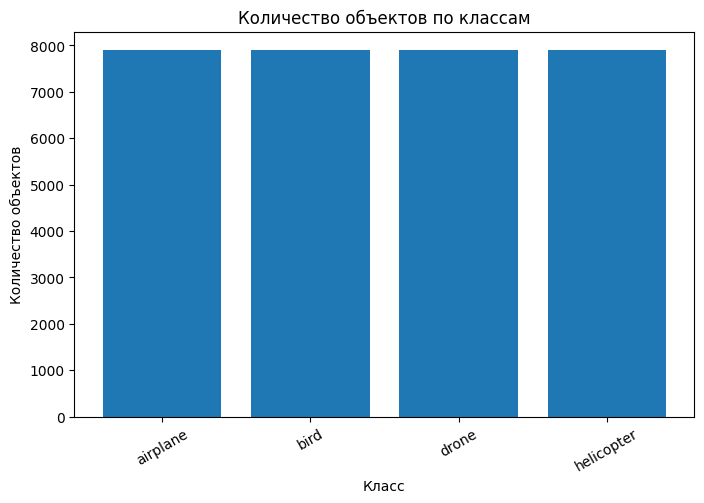

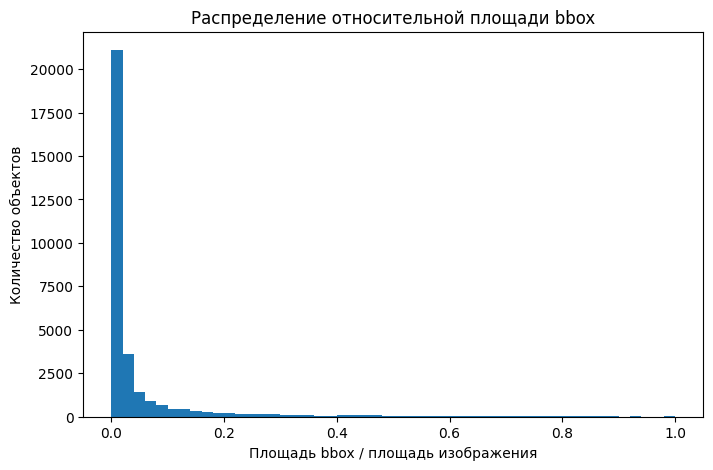

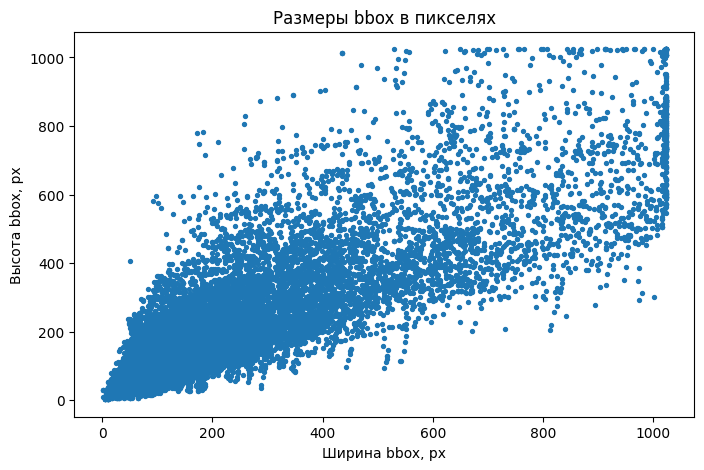

In [8]:
# ==========================
# ГРАФИКИ
# ==========================

if class_rows:
    class_names = [row["class_name"] for row in class_rows]
    class_counts = [row["total_objects"] for row in class_rows]

    plt.figure(figsize=(8, 5))
    plt.bar(class_names, class_counts)
    plt.title("Количество объектов по классам")
    plt.xlabel("Класс")
    plt.ylabel("Количество объектов")
    plt.xticks(rotation=30)
    plt.show()

if bbox_rows:
    relative_areas = [row["relative_area"] for row in bbox_rows]

    plt.figure(figsize=(8, 5))
    plt.hist(relative_areas, bins=50)
    plt.title("Распределение относительной площади bbox")
    plt.xlabel("Площадь bbox / площадь изображения")
    plt.ylabel("Количество объектов")
    plt.show()

    bbox_widths = [row["bbox_width_px"] for row in bbox_rows]
    bbox_heights = [row["bbox_height_px"] for row in bbox_rows]

    plt.figure(figsize=(8, 5))
    plt.scatter(bbox_widths, bbox_heights, s=8)
    plt.title("Размеры bbox в пикселях")
    plt.xlabel("Ширина bbox, px")
    plt.ylabel("Высота bbox, px")
    plt.show()

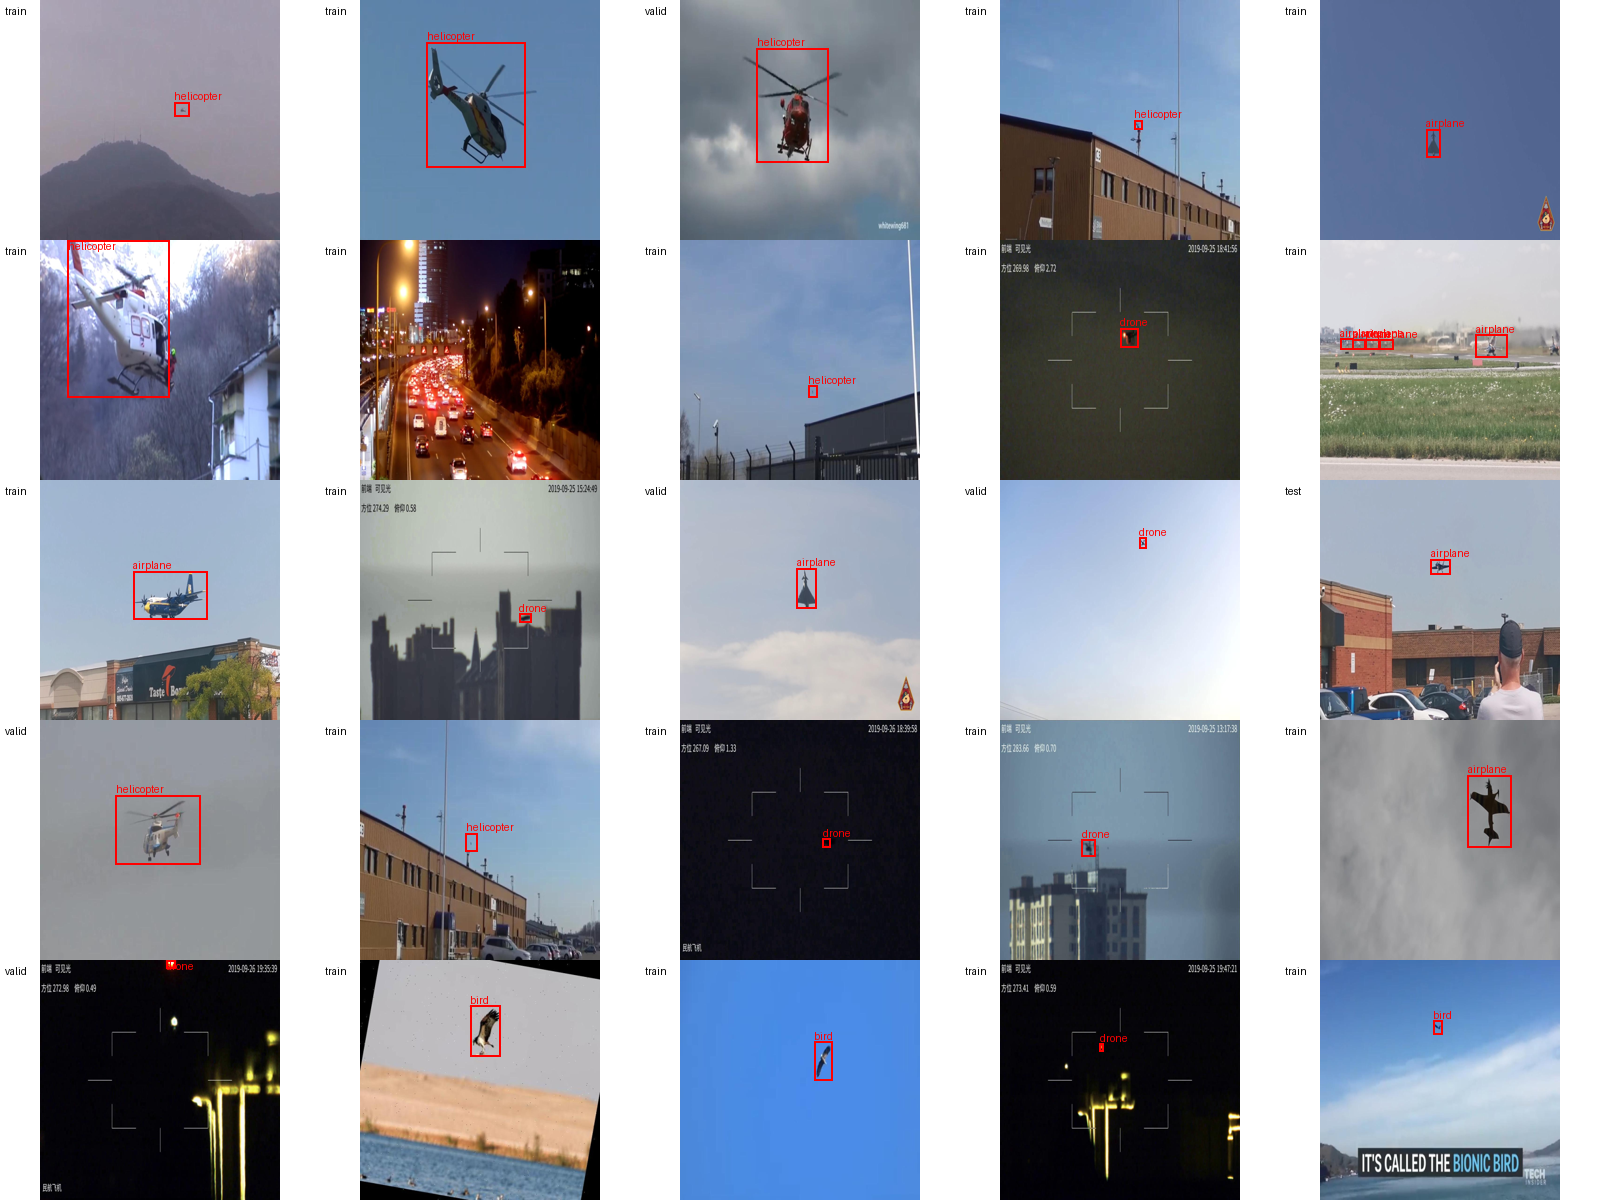

In [9]:
# ==========================
# ВИЗУАЛЬНАЯ ПРОВЕРКА РАЗМЕТКИ
# ==========================

def draw_sample_grid(sample_count=25):
    available_images = []

    for split in SPLITS:
        image_folder = IMAGES_ROOT / split
        label_folder = LABELS_ROOT / split / "labels"

        if not image_folder.exists() or not label_folder.exists():
            continue

        for image_path in get_all_images(image_folder):
            label_path = label_folder / f"{image_path.stem}.txt"
            if label_path.exists():
                available_images.append((split, image_path, label_path))

    if not available_images:
        return

    sample = random.sample(available_images, min(sample_count, len(available_images)))

    cell_width = 320
    cell_height = 240
    columns = 5
    rows = (len(sample) + columns - 1) // columns

    grid = Image.new("RGB", (columns * cell_width, rows * cell_height), "white")
    draw_grid = ImageDraw.Draw(grid)

    for index, (split, image_path, label_path) in enumerate(sample):
        with Image.open(image_path).convert("RGB") as image:
            original_width, original_height = image.size

            image.thumbnail((cell_width, cell_height))
            resized_width, resized_height = image.size

            x_offset = (index % columns) * cell_width
            y_offset = (index // columns) * cell_height

            paste_x = x_offset + (cell_width - resized_width) // 2
            paste_y = y_offset + (cell_height - resized_height) // 2

            grid.paste(image, (paste_x, paste_y))

            scale_x = resized_width / original_width
            scale_y = resized_height / original_height

            objects, _ = parse_yolo_label(label_path)
            draw = ImageDraw.Draw(grid)

            for obj in objects:
                class_id = obj["class_id"]
                class_name = CLASS_NAMES.get(class_id, f"class_{class_id}")

                x_min = paste_x + obj["x_min_norm"] * original_width * scale_x
                y_min = paste_y + obj["y_min_norm"] * original_height * scale_y
                x_max = paste_x + obj["x_max_norm"] * original_width * scale_x
                y_max = paste_y + obj["y_max_norm"] * original_height * scale_y

                draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)
                draw.text((x_min, max(y_min - 12, paste_y)), class_name, fill="red")

            draw_grid.text((x_offset + 5, y_offset + 5), split, fill="black")
    display(grid)

draw_sample_grid(sample_count=25)

In [10]:
# ==========================
# КРАТКИЙ ИТОГ В КОНСОЛЬ
# ==========================

print("\nГотово.")
print(f"Папка с результатами: {OUTPUT_ROOT}")

print("\nКоличество изображений:")
for split in SPLITS:
    count = sum(1 for row in image_rows if row["split"] == split)
    print(f"{split}: {count}")

print("\nКоличество объектов по классам:")
for class_id, count in sorted(class_counter_total.items()):
    print(f"{CLASS_NAMES.get(class_id, f'class_{class_id}')}: {count}")

print(f"\nИзображений без label-файла: {len(missing_labels)}")
print(f"Пустых label-файлов: {len(empty_labels)}")
print(f"Label-файлов без изображения: {len(missing_images_for_labels)}")
print(f"Ошибок в разметке: {len(all_errors)}")


Готово.
Папка с результатами: F:\kurs_work\AOD 4\AOD 4\analysis

Количество изображений:
train: 15761
valid: 4514
test: 2241

Количество объектов по классам:
airplane: 7900
bird: 7900
drone: 7898
helicopter: 7900

Изображений без label-файла: 0
Пустых label-файлов: 596
Label-файлов без изображения: 0
Ошибок в разметке: 0


In [11]:
errors_path = Path(r"C:\Users\IvanC\kurs_work\AOD 4\analysis\errors.csv")

if errors_path.exists():
    with open(errors_path, "r", encoding="utf-8-sig") as file:
        print(file.read())
else:
    print("Файл errors.csv не найден")

Файл errors.csv не найден


In [12]:
images_df = pd.DataFrame(image_rows)
bbox_df = pd.DataFrame(bbox_rows)

split_summary = []

for split in SPLITS:
    split_images = images_df[images_df["split"] == split]
    split_bboxes = bbox_df[bbox_df["split"] == split]

    split_summary.append({
        "Выборка": split,
        "Изображений": len(split_images),
        "Объектов": len(split_bboxes),
        "Пустых изображений": int((split_images["objects_count"] == 0).sum()),
        "Среднее объектов на изображение": round(split_images["objects_count"].mean(), 3),
        "Максимум объектов на изображение": int(split_images["objects_count"].max()),
    })

split_summary_df = pd.DataFrame(split_summary)
display(split_summary_df)

,Выборка,Изображений,Объектов,Пустых изображений,Среднее объектов на изображение,Максимум объектов на изображение
0,train,15761,22058,415,1.400,36
1,valid,4514,6369,125,1.411,36
2,test,2241,3171,56,1.415,35


In [13]:
class_table = (
    bbox_df
    .pivot_table(
        index="class_name",
        columns="split",
        values="image_name",
        aggfunc="count",
        fill_value=0
    )
)

class_table["total"] = class_table.sum(axis=1)
class_table = class_table.reset_index()

display(class_table)

split,class_name,test,train,valid,total
0,airplane,767,5508,1625,7900
1,bird,821,5522,1557,7900
2,drone,796,5500,1602,7898
3,helicopter,787,5528,1585,7900


In [14]:
size_table = (
    bbox_df
    .pivot_table(
        index="class_name",
        columns="size_category",
        values="image_name",
        aggfunc="count",
        fill_value=0
    )
)

size_table["total"] = size_table.sum(axis=1)
size_table = size_table.reset_index()

display(size_table)

size_category,class_name,large,medium,small,tiny,total
0,airplane,1080,1316,2166,3338,7900
1,bird,319,1068,2072,4441,7900
2,drone,43,66,702,7087,7898
3,helicopter,778,1437,3098,2587,7900


In [15]:
format_table = (
    bbox_df
    .pivot_table(
        index="source_format",
        columns="split",
        values="image_name",
        aggfunc="count",
        fill_value=0
    )
)

format_table["total"] = format_table.sum(axis=1)
format_table = format_table.reset_index()

display(format_table)

split,source_format,test,train,valid,total
0,bbox,3171,22055,6369,31595
1,polygon_converted_to_bbox,0,3,0,3
